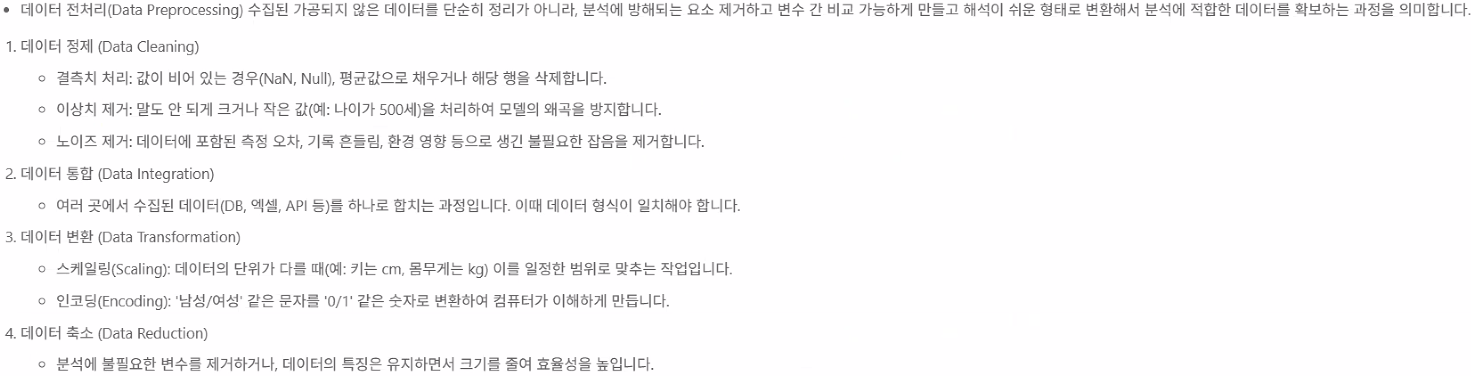

---

시리즈 결측치 처리

In [1]:
import pandas as pd
score = pd.Series([30, 20, 40, pd.NA, 30, pd.NA])
print(score)

0      30
1      20
2      40
3    <NA>
4      30
5    <NA>
dtype: object


In [2]:
print(score.sum())

120


In [3]:
print(score.mean())

30.0


In [4]:
print(score + 5)

0      35
1      25
2      45
3    <NA>
4      35
5    <NA>
dtype: object


In [5]:
print(pd.isna(score))

0    False
1    False
2    False
3     True
4    False
5     True
dtype: bool


In [6]:
print(pd.isna(score).sum())

2


In [7]:
print(score.size) # including NA
print(score.count()) # except NA

6
4


In [8]:
print(pd.notna(score))

0     True
1     True
2     True
3    False
4     True
5    False
dtype: bool


In [9]:
print(pd.notna(score).sum())

4


In [10]:
score = score.dropna()
print(score)

0    30
1    20
2    40
4    30
dtype: object


In [11]:
score = score.reset_index(drop=True)
print(score)

0    30
1    20
2    40
3    30
dtype: object


---
데이터프레임 결측치 처리

In [12]:
import numpy as np

df = pd.read_csv('data/iris.csv')

df.iloc[0, 1] = pd.NA
df.iloc[0, 2] = pd.NA
df.iloc[1, 2] = np.nan
df.iloc[2, 3] = None
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,NaN,NaN,0.2,setosa
1,4.9,3.0,NaN,0.2,setosa
2,4.7,3.2,1.3,NaN,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
결측치 확인

In [13]:
result = df.isna()
print(type(result))
print(result)

<class 'pandas.DataFrame'>
     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width  Species
0           False         True          True        False    False
1           False        False          True        False    False
2           False        False         False         True    False
3           False        False         False        False    False
4           False        False         False        False    False
..            ...          ...           ...          ...      ...
145         False        False         False        False    False
146         False        False         False        False    False
147         False        False         False        False    False
148         False        False         False        False    False
149         False        False         False        False    False

[150 rows x 5 columns]


In [14]:
result = df.isna().sum()
print(type(result))
print(result)

<class 'pandas.Series'>
Sepal_Length    0
Sepal_Width     1
Petal_Length    2
Petal_Width     1
Species         0
dtype: int64


In [15]:
result = df.isna().any()

print(type(result))
print(result)

<class 'pandas.Series'>
Sepal_Length    False
Sepal_Width      True
Petal_Length     True
Petal_Width      True
Species         False
dtype: bool


In [16]:
print(df.isna().any(axis=1)) # 행 별로 결측치 확인

0       True
1       True
2       True
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool


In [17]:
result = df.isna().sum(axis=1)
print(type(result))
print(result)

<class 'pandas.Series'>
0      2
1      1
2      1
3      0
4      0
      ..
145    0
146    0
147    0
148    0
149    0
Length: 150, dtype: int64


In [18]:
result = df[df.isna().any(axis=1)]
result

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,NaN,NaN,0.2,setosa
1,4.9,3.0,NaN,0.2,setosa
2,4.7,3.2,1.3,NaN,setosa


---
결측치 제거

In [19]:
df = df.dropna()
df

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [20]:
df = df.reset_index(drop=True)
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,4.6,3.1,1.5,0.2,setosa
1,5.0,3.6,1.4,0.2,setosa
2,5.4,3.9,1.7,0.4,setosa
3,4.6,3.4,1.4,0.3,setosa
4,5.0,3.4,1.5,0.2,setosa


---
결측치 추청

In [21]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd

from sklearn.impute import KNNImputer

# 데이터 범위를 0과 1 사이로 스케일링 (KNN은 거리 기반이므로 스케일링이 필요)
from sklearn.preprocessing import MinMaxScaler

df_org = pd.read_csv('data/iris.csv')
df_miss = df_org.copy()

df_miss.iloc[0, 3] = pd.NA
df_miss.iloc[0, 2] = pd.NA
df_miss.iloc[1, 2] = None
df_miss.iloc[2, 3] = None

df_miss.head(4)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,NaN,NaN,setosa
1,4.9,3.0,NaN,0.2,setosa
2,4.7,3.2,1.3,NaN,setosa
3,4.6,3.1,1.5,0.2,setosa


---
## 데이터 전처리: 스케일링 (Scaling)
### 1. 스케일링이란?
변수(컬럼)의 값 범위를 일정한 기준으로 맞추는 작업을 말합니다.  
서로 다른 단위와 범위를 가진 데이터들을 동일한 선상에서 비교할 수 있게 합니다.

---
### 2. 왜 필요한가?
* 단위의 불일치: 데이터마다 측정 단위와 범위가 다릅니다.
* 계산의 왜곡 방지: 특정 변수의 숫자가 너무 크면 모델이 해당 변수를 과도하게 중요하다고 판단할 수 있습니다.
* 공평한 영향력: 스케일링을 통해 각 변수가 모델 학습에 공평하게 기여하도록 조정합니다.
    | 변수 | 값 범위 | 특징 |
    | :--- | :--- | :--- |
    | 키(cm) | 150 ~ 190 | 비교적 좁은 범위 |
    | 몸무게(kg) | 45 ~ 90 | 중간 범위 |
    | 연봉(원) | 2,000만 ~ 1억 | 매우 큰 범위 (계산 지배 가능) |
---
### 3. 스케일링의 종류
| 방법 | 특징 | 공식 |
| :--- | :--- | :--- |
| Min-Max 스케일링 | 모든 값을 0~1 사이로 변환 (정규화) | $X_{scaled} = \frac{X - X_{min}}{X_{max}-X_{min}}$ |
| 표준화 (Standardization) | 데이터를 평균 0, 표준편차 1인 형태로 변환 | $Z = \frac{X - \mu}{\sigma}$ |
| Robust 스케일링 | 중앙값과 IQR을 사용하여 이상치 영향 최소화 | $X_{scaled} = \frac{X - Q_2}{Q_3 - Q_1}$ |
| Log 변환 | 한쪽으로 크게 치우친(Skewed) 데이터 완화 | $X_{log} = \log(X+1)$ |
---
### 왜도 (Skewness)
데이터 분포의 비대칭 정도를 수치로 나타낸 것입니다.
1. 정규분포: 왜도가 0이며 좌우 대칭인 분포입니다.
2. 양의 왜도 (Positive Skew): 오른쪽으로 꼬리가 긴 분포 (데이터가 왼쪽에 집중됨)
3. 음의 왜도 (Negative Skew): 왼쪽으로 꼬리가 긴 분포 (데이터가 오른쪽에 집중됨)
---
- scaler = MinMaxScaler()
    - 결측치가 포함된 데이터를 처리하기 전에, 데이터의 범위를 0에서 1 사이로 맞추는 스케일링(Scaling) 과정을 수행하는 코드입니다.
    - 데이터의 모든 값을 0에서 1 사이로 변환하는 MinMax 정규화를 적용합니다.
    - $x_{scaled} = \frac{x-x_{min}}{x_{max}-x_{min}}$
- scaler.fit_transform(df_miss.iloc[:, :4]) 의미
    - fit_transform()는 두 가지 작업을 한 번에 수행합니다.
    - fit(): 데이터의 각 열(column)에서 최솟값($x_{min}$)과 최댓값($x_{max}$)을 계산해서 기억합니다.
        - 예) 내부적으로 저장되는 값 ( sepal_length_min, sepal_length_max, ... )
    - transform(): fit()에서 기억한 min/max를 이용해 모든 값을 0~1 사이 값으로 변환합니다.
- df_miss.iloc[:, :4]
    - iris 데이터에서 수치형 데이터가 있는 앞의 4개 열(Sepal length, Sepal width, Petal length, Petal width)만 선택해서 스케일링 하겠다는 뜻입니다.
- df_scaled[0:5, :]
    - 스케일링이 완료된 결과물(df_scaled)에서 상위 5개의 행(0번~4번)과 모든 열(:)을 화면에 보여달라는 뜻입니다.
    - fit_transform()의 결과물은 넘파이 배열(NumPy Array) 형태라 슬라이싱 방식을 이용해 확인합니다.

In [23]:
# (1) 데이터 정규화 (Normalization)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_miss.iloc[:, :4])
print(df_scaled[0:5, :])

[[0.22222222 0.625             nan        nan]
 [0.16666667 0.41666667        nan 0.04166667]
 [0.11111111 0.5        0.05084746        nan]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


---
- imputer = KNNImputer(n_neighbors=5)
    - KNNImputer: KNN(K-Nearst Neighbors, 최근접 이웃) 알고리즘을 사용하여 결측치를 채우는 클래스입니다.
    - n_neighbors=5: 가장 중요한 설정값(하이퍼파라미터)입니다.
        - 빈칸이 있는 데이터와 가장 비슷한 이웃 5개를 찾으라는 뜻입니다.
- df_scaled = imputer.fit_transform(df_scaled)
    - 이 문장은 실제로 데이터를 분석해서 빈칸을 계산하고 채우는 단계입니다. 내부적으로 두 가지 작업이 동시에 일어납니다.
    - fit(): 결측치가 있는 행과 나머지 모든 행 사이의 거리를 구하고 각 결측치 행마다 가장 거리가 가까운 상위 K개(여기서는 5개)의 행을 찾아냅니다.
    - transform(): 선정된 5개 이웃의 해당 열 값들을 가져와서 빈칸에 넣을 값을 계산 후 실제 NaN(결측치)이 있는 칸에 계산된 값을 집어넣습니다.

In [24]:
# (2) 결측치 추정
imputer = KNNImputer(n_neighbors=5)
df_scaled = imputer.fit_transform(df_scaled)
print('--- 결측치 추정 완료 (0~1 스케일 상태) ---')
print(df_scaled[0:5, :])

--- 결측치 추정 완료 (0~1 스케일 상태) ---
[[0.22222222 0.625      0.0779661  0.09166667]
 [0.16666667 0.41666667 0.08474576 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


In [25]:
# (3) 정규화 이전으로 변환
df_filled = scaler.inverse_transform(df_scaled)
print('\n--- 원래 단위로 복구된 데이터 (상위 행) ---')
print(df_filled[:5])


--- 원래 단위로 복구된 데이터 (상위 행) ---
[[5.1  3.5  1.46 0.32]
 [4.9  3.   1.5  0.2 ]
 [4.7  3.2  1.3  0.2 ]
 [4.6  3.1  1.5  0.2 ]
 [5.   3.6  1.4  0.2 ]]


In [26]:
# 결측치가 있던 df_miss에 계산된 값 채워넣기
df_miss.iloc[:, :4] = df_filled

In [27]:
# (4) 결과 비교 확인
print("\n--- [비교] 결측치가 채워진 데이터 (df_miss) ---")
print(df_miss.head(4))

print("\n--- [비교] 실제 원본 데이터 (df_org) ---")
print(df_org.head(4))


--- [비교] 결측치가 채워진 데이터 (df_miss) ---
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5          1.46         0.32  setosa
1           4.9          3.0          1.50         0.20  setosa
2           4.7          3.2          1.30         0.20  setosa
3           4.6          3.1          1.50         0.20  setosa

--- [비교] 실제 원본 데이터 (df_org) ---
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa


---
- Outlier(이상치) 란 대부분의 데이터 분포에서 유난히 멀리 떨어져 있는 값을 말합니다.
- 이상치가 생기는 이유
    | **원인** | **설명** |
    | :--- | :--- |
    | 입력 오류 | 80 → 800 |
    | 측정 오류 | 센서 오작동 |
    | 실제 특이 현상 | 폭우, 사고 |
    | 다른 집단 | 전혀 다른 특성 |
- 대표적인 이상치 판별법
    1. IQR 방법
        - Q1: 1사분위수, Q3: 3사분위수, IQR = Q3 - Q1
        - Lower Bound=Q1-1.5xIQR
        - Upper Bound=Q3+1.5xIQR
        - Lower Bound 보다 작거나 Upper Bound 보다 크면 이상치
    2. Z-score 방법
        - 데이터 값들이 평균으로부터 표준편차에 비해 얼마나 떨어져 있는지를 나타낸 것입니다.

            $Z=\frac{x-\mu}{\sigma}$
        - 예)
            | **Z-score 값** | **평균과의 관계** | **의미 설명** |
            | :--- | :--- | :--- |
            | z = 0 | 평균과 같음 | 데이터 값이 평균과 정확히 동일합니다 |
            | z = 1 | 평균보다 큼 | 평균보다 표준편차 1배만큼 큼 |
            | z = 2 | 평균보다 큼 | 평균보다 표준편차 1배만큼 큼 |
            | z = 3 | 평균보다 큼 | 평균보다 표준편차 1배만큼 큼 → 매우 큰 값 |
            | z = -1 | 평균보다 작음 | 평균보다 표준편차 1배만큼 작음 |
            | z = -2 | 평균보다 작음 | 평균보다 표준편차 1배만큼 작음 |
            | z = -3 | 평균보다 작음 | 평균보다 표준편차 1배만큼 작음 -> 매우 작은 값 |
        - |z| 값이 클수록 평균에서 멀리 떨어진 값이며, 이상치일 가능성이 커집니다.

In [28]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('data/iris.csv')
sw = df.Sepal_Width

# Z-score 이용
z = np.abs(stats.zscore(sw)) # z 절댓값이 2보다 크면 이상치로 판단
outliers = sw[z > 2]         # 2 = 입계값
outliers

14    4.0
15    4.4
32    4.1
33    4.2
60    2.0
Name: Sepal_Width, dtype: float64

In [29]:
# IQR 이용
Q1= sw.quantile(0.25)
Q3 = sw.quantile(0.75)
IQR = Q3 - Q1

outliers = sw[(sw < Q1 - IQR*1.5) | (sw > Q3 + IQR*1.5)]
outliers

15    4.4
32    4.1
33    4.2
60    2.0
Name: Sepal_Width, dtype: float64

---
## 이상치 탐지 및 탐색적 데이터 분석 (EDA)
데이터 분석과 모델링에 앞서 데이터의 특성을 파악하고 정제하는 과정은 분석 결과의 신뢰도를 결정하는 핵심 단계입니다.
1. 이상치 탐지
    - Z-score vs IQR
    - 이상치는 정의하는 기준에 따라 결과가 달라지므로, 데이터의 분포와 분석 목적에 맞춰 선택해야 합니다.
2. 주요 특징 비교

    | **비교 항목** | **Z-score (Standard Score)** | **IQR (Iterquartile Range)** |
    | :--- | :--- | :--- |
    | 중심 기준 | 평균($\mu$)과 표준편차($\sigma$) 중심 | 중앙값(Median)과 사분위수 중심 |
    | 계산 방식 | 평균에서 표준편차의 $n$배만큼 떨어진 값 | $Q3 + 1.5 \times IQR$ 보다 크거나 $Q1 - 1.5 \times IQR$ 보다 작은 값 |
    | 특징 | 데이터가 정규분포일 때 매우 정교함 | 데이터가 치우쳐 있거나 분포를 모를 때 안정적임 |

3. 상황별 선택
    - Z-score: 데이터가 정규분포를 만족할 때, 통계적 엄격함이 필요할 때.
    - IQR: 분포를 모르거나 왜곡(Skewed) 되었을 때, EDA 단계에서 시각적으로 확인할 때.
    - 머신러닝: 두 방식을 모두 비교하여 모델 성능 (Accuracy 등)이 더 좋은 기준을 채택.
---
정렬

In [30]:
df = pd.read_csv('data/iris.csv')

df_sorted = df.sort_values('Sepal_Length')
df_sorted.head(10)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
13,4.3,3.0,1.1,0.1,setosa
8,4.4,2.9,1.4,0.2,setosa
42,4.4,3.2,1.3,0.2,setosa
38,4.4,3.0,1.3,0.2,setosa
41,4.5,2.3,1.3,0.3,setosa
22,4.6,3.6,1.0,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
6,4.6,3.4,1.4,0.3,setosa
47,4.6,3.2,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [31]:
df_sorted = df.sort_values('Sepal_Length', ascending=False)
df_sorted.head(10)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
131,7.9,3.8,6.4,2.0,virginica
122,7.7,2.8,6.7,2.0,virginica
118,7.7,2.6,6.9,2.3,virginica
117,7.7,3.8,6.7,2.2,virginica
135,7.7,3.0,6.1,2.3,virginica
105,7.6,3.0,6.6,2.1,virginica
130,7.4,2.8,6.1,1.9,virginica
107,7.3,2.9,6.3,1.8,virginica
109,7.2,3.6,6.1,2.5,virginica
129,7.2,3.0,5.8,1.6,virginica


In [32]:
df_sorted = df.sort_values(['Species', 'Sepal_Width'])
df_sorted.head(10)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
41,4.5,2.3,1.3,0.3,setosa
8,4.4,2.9,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
12,4.8,3.0,1.4,0.1,setosa
13,4.3,3.0,1.1,0.1,setosa
25,5.0,3.0,1.6,0.2,setosa
38,4.4,3.0,1.3,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa
3,4.6,3.1,1.5,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


---
ranking(순위)
- 순위 산정 방식 옵션<br>
    method='average'(기본)

In [33]:
import pandas as pd

data = {'Score': [10, 20, 20, 30]}
df_test = pd.DataFrame(data)

df_test['average'] = df_test['Score'].rank(method='average')
df_test['min']     = df_test['Score'].rank(method='min')
df_test['max']     = df_test['Score'].rank(method='max')
df_test['first']   = df_test['Score'].rank(method='first')
df_test['dense']   = df_test['Score'].rank(method='dense')

df_test

,Score,average,min,max,first,dense
0,10,1.0,1.0,1.0,1.0,1.0
1,20,2.5,2.0,3.0,2.0,2.0
2,20,2.5,2.0,3.0,3.0,2.0
3,30,4.0,4.0,4.0,4.0,3.0


---
iris.csv를 이용한 예제

In [34]:
df = pd.read_csv('data/iris.csv')

df['Petal_Length'].rank().head()

0    18.0
1    18.0
2     8.0
3    31.0
4    18.0
Name: Petal_Length, dtype: float64

In [35]:
df['Petal_Length'].rank().astype(int)

0       18
1       18
2        8
3       31
4       18
      ... 
145    117
146    106
147    117
148    121
149    112
Name: Petal_Length, Length: 150, dtype: int64

In [36]:
df['Petal_Length'].rank(ascending=False).astype(int)

0      133
1      133
2      143
3      120
4      133
      ... 
145     33
146     44
147     33
148     29
149     38
Name: Petal_Length, Length: 150, dtype: int64

---
데이터 샘플링(Data Sampling)이란 전체 데이터(모집단)를 모두 분석하기 어려울 때, 그중 일부인 표본(Sample)을 추출하여 전체의 특성을 추론하는 통계적 기법입니다.
1. Random Sampling

In [37]:
import pandas as pd
import itertools

df = pd.read_csv('data/iris.csv')

df20 = df.sample(n=20, random_state=123)
df20

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
72,6.3,2.5,4.9,1.5,versicolor
112,6.8,3.0,5.5,2.1,virginica
132,6.4,2.8,5.6,2.2,virginica
88,5.6,3.0,4.1,1.3,versicolor
37,4.9,3.6,1.4,0.1,setosa
138,6.0,3.0,4.8,1.8,virginica
87,6.3,2.3,4.4,1.3,versicolor
42,4.4,3.2,1.3,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
90,5.5,2.6,4.4,1.2,versicolor


---
2. 층화 샘플링 (Stratified Sampling) 전체 데이터를 서로 중복되지 않는 여러 개의 하위 집단 (층, Strata)으로 나눈 뒤, 각 집단 내에서 독립적으로 무작위 추출을 수행하는 방법입니다.

In [38]:
# Species 기준 그룹화
groups = df.groupby('Species')
groups

In [39]:
groups.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [40]:
# 층화 샘플링 (stratified sampling)
# species 별로 데이터를 나눈 뒤, 각 그룹에서 20%씩 무작위로 추출하여 비율을 유지한 표본을 만듭니다.
# x.sample(frac=0.2, random_state=123) L 각 품종 그룹에서 20% 비율로 무작위 추출합니다. (각 품종 그룹의 수 50개 * 0.2 = 10개)
stratified = df.groupby('Species').sample(frac=0.2, random_state=123)
stratified

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
10,5.4,3.7,1.5,0.2,setosa
13,4.3,3.0,1.1,0.1,setosa
30,4.8,3.1,1.6,0.2,setosa
46,5.1,3.8,1.6,0.2,setosa
18,5.7,3.8,1.7,0.3,setosa
0,5.1,3.5,1.4,0.2,setosa
40,5.0,3.5,1.3,0.3,setosa
12,4.8,3.0,1.4,0.1,setosa
29,4.7,3.2,1.6,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa


---
combinations(조합)
- combinations는 여러 개 중에서 중복은 없고 순서와 상관없이 정해진 개수만큼 뽑느 모든 경우의 수(조합)를 만듭니다.

In [41]:
# Species 열에 존재하는 고유한 값만 추출
species = df.Species.unique()
species

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

In [42]:
comb = list(itertools.combinations(species, 2))
comb

[('setosa', 'versicolor'),
 ('setosa', 'virginica'),
 ('versicolor', 'virginica')]

---
데이터 집계(aggregation)은 데이터프레임과 같은 2차원 데이터에서 데이터 그룹에 대한 합계나 평균을 계산하는 작업입니다.
- 집계를 수행하려면 groupby() 메서드를 이용합니다.

In [43]:
df = pd.read_csv('data/iris.csv')

df_agg = df.groupby('Species').mean()
df_agg

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [44]:
df_agg = df.groupby('Species').std()
df_agg

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
Species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


In [45]:
df_agg = df.groupby('Species').max()
df_agg

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
Species,,,,
setosa,5.8,4.4,1.9,0.6
versicolor,7.0,3.4,5.1,1.8
virginica,7.9,3.8,6.9,2.5


In [46]:
df_agg = df.groupby('Species').min()
df_agg

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
Species,,,,
setosa,4.3,2.3,1.0,0.1
versicolor,4.9,2.0,3.0,1.0
virginica,4.9,2.2,4.5,1.4


In [47]:
# 컬럼마다 맞춤형 통계 적용
# agg({ ... }): agg는 집계(aggregation)의 약자로, 여러 통계 함수를 dict 형으로 한번에 적용하겠다는 뜻입니다.
df_custom = df.groupby('Species').agg({
    'Sepal_Length': 'mean',
    'Petal_Length': 'max',
    'Sepal_Width': 'count'
})
df_custom

,Sepal_Length,Petal_Length,Sepal_Width
Species,,,
setosa,5.006,1.9,50
versicolor,5.936,5.1,50
virginica,6.588,6.9,50


In [48]:
# Species 별로 Petal_Length의 범위를 계산
df_range = df.groupby('Species')['Petal_Length'].apply(lambda x: x.max() - x.min())
df_range

Species
setosa        0.9
versicolor    2.1
virginica     2.4
Name: Petal_Length, dtype: float64

---
그룹핑 그룹이 두 개인 경우

In [49]:
pd.set_option('display.expand_frame_repr', False) # False는 줄바꿈을 없애고 ...으로 생략함

In [50]:
df = pd.read_csv('data/mtcars.csv')
df[df['cyl'] == 4]

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
20,Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2


In [51]:
df_agg = df.groupby(['cyl', 'vs']).max()
df_agg

model   mpg   disp   hp  drat     wt   qsec  am  gear  carb
cyl vs                                                                        
4   0      Porsche 914-2  26.0  120.3   91  4.43  2.140  16.70   1     5     2
    1         Volvo 142E  33.9  146.7  113  4.93  3.190  22.90   1     5     2
6   0      Mazda RX4 Wag  21.0  160.0  175  3.90  2.875  17.02   1     5     6
    1            Valiant  21.4  258.0  123  3.92  3.460  20.22   0     4     4
8   0   Pontiac Firebird  19.2  472.0  335  4.22  5.424  18.00   1     5     8

---
데이터 병함(merge)은 흩어진 데이터를 하나로 모으는 작업을 의미합니다.

In [52]:
df1 = pd.DataFrame([[169, 58, 1.0],
                    [172, 73, 1.2],
                    [184, 82, 0.7]],
                columns=['height', 'weight', 'eye'])
df2 = pd.DataFrame([[176, 71, 0.8, 'M'],
                    [169, 62, 0.7, 'F'],
                    [158, 60, 1.3, 'M']],
                columns=['height', 'weight', 'eye', 'gender'])
df3 = pd.DataFrame([[3, 22],
                    [2, 21]],
                columns=['grade', 'age'])

In [53]:
df1

,height,weight,eye
0,169,58,1.0
1,172,73,1.2
2,184,82,0.7


In [54]:
df2

,height,weight,eye,gender
0,176,71,0.8,M
1,169,62,0.7,F
2,158,60,1.3,M


In [55]:
df3

,grade,age
0,3,22
1,2,21


In [56]:
df12 = pd.concat([df1, df2])
df12

,height,weight,eye,gender
0,169,58,1.0,NaN
1,172,73,1.2,NaN
2,184,82,0.7,NaN
0,176,71,0.8,M
1,169,62,0.7,F
2,158,60,1.3,M


In [57]:
df12 = df12.reset_index(drop=True)
df12

,height,weight,eye,gender
0,169,58,1.0,NaN
1,172,73,1.2,NaN
2,184,82,0.7,NaN
3,176,71,0.8,M
4,169,62,0.7,F
5,158,60,1.3,M


In [58]:
df13 = pd.concat([df1, df3], axis=1)
df13

,height,weight,eye,grade,age
0,169,58,1.0,3.0,22.0
1,172,73,1.2,2.0,21.0
2,184,82,0.7,NaN,NaN


In [59]:
df12 = pd.concat([df1, df2], axis=1)
df12

,height,weight,eye,height,weight,eye,gender
0,169,58,1.0,176,71,0.8,M
1,172,73,1.2,169,62,0.7,F
2,184,82,0.7,158,60,1.3,M


---
공통 컬럼에 대한 병합
- Pandas의 merge() 함수는 두 개의 데이터프레임을 공통된 열(Key)이나 인덱스를 기준으로 하나의 데이터프레임으로 결합하는 함수입니다.

    | **방식 (how)** | **설명** | **비고** |
    | :--- | :--- | :--- |
    | inner (기본값) | 두 데이터프레임의 공통된 키(Key)값이 있는 행들만 골라 합칩니다 | 교집합 |
    | left | 왼쪽(df1)의 모든 행을 유지하고, 오른쪽은 맞는 것만 병합합니다. | 왼쪽 기준 |
    | right | 오른쪽(df2)의 모든 행을 유지하고, 왼쪽은 맞는 것만 병합합니다. | 오른쪽 기준 |
    | outer | 양쪽 중 한쪽에라도 존재하면 모두 포함합니다. | 합집합 |
    | cross | 모든 가능한 행의 조합을 만듭니다 | 카테시안 곱 |

In [60]:

df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                   columns=['name', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                   columns=['name', 'math'])

In [61]:
df1

,name,kor
0,a,90
1,b,80
2,c,40


In [62]:
df2

,name,math
0,a,75
1,b,60
2,d,90


In [63]:
# 교차 결합(Cross join)은 df1의 모든 행과 df2의 모든 행을 빠짐없이 조합하는 의미이다.
# 행이 각각 3개씩 이므로, 결과는 3 x 3 = 9개의 행이 생성된다.
df1.merge(df2, how='cross')

,name_x,kor,name_y,math
0,a,90,a,75
1,a,90,b,60
2,a,90,d,90
3,b,80,a,75
4,b,80,b,60
5,b,80,d,90
6,c,40,a,75
7,c,40,b,60
8,c,40,d,90


In [64]:
df12 = df1.merge(df2, on='name')
df12

,name,kor,math
0,a,90,75
1,b,80,60


In [65]:
df12.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    2 non-null      str  
 1   kor     2 non-null      int64
 2   math    2 non-null      int64
dtypes: int64(2), str(1)
memory usage: 180.0 bytes


In [66]:
df12 = df1.merge(df2, how='left', on='name')
df12

,name,kor,math
0,a,90,75.0
1,b,80,60.0
2,c,40,NaN


In [67]:
print(df2['math'].dtype)
print(df12['math'].dtype) # NaN은 float형으로 처리되므로 float64형으로 컬럼이 바뀐다.
print(df12.info())

int64
float64
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    3 non-null      str    
 1   kor     3 non-null      int64  
 2   math    2 non-null      float64
dtypes: float64(1), int64(1), str(1)
memory usage: 204.0 bytes
None


In [68]:
df12 = df1.merge(df2, how='right', on='name')
df12

,name,kor,math
0,a,90.0,75
1,b,80.0,60
2,d,NaN,90


In [69]:
df12 = df1.merge(df2, how='outer', on='name')
df12

,name,kor,math
0,a,90.0,75.0
1,b,80.0,60.0
2,c,40.0,NaN
3,d,NaN,90.0


---
공통 컬럼으로 사용할 컬럼이 다른 경우

In [70]:
df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                   columns=['name1', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                   columns=['name2', 'math'])

In [71]:
df12 = df1.merge(df2, left_on='name1', right_on='name2')
df12

,name1,kor,name2,math
0,a,90,a,75
1,b,80,b,60


In [72]:
df12 = df1.merge(df2, how='left', left_on='name1', right_on='name2')
df12

,name1,kor,name2,math
0,a,90,a,75.0
1,b,80,b,60.0
2,c,40,NaN,NaN


In [73]:
df12 = df1.merge(df2, how='right', left_on='name1', right_on='name2')
df12

,name1,kor,name2,math
0,a,90.0,a,75
1,b,80.0,b,60
2,NaN,NaN,d,90


In [74]:
df12 = df1.merge(df2, how='outer', left_on='name1', right_on='name2')
df12

,name1,kor,name2,math
0,a,90.0,a,75.0
1,b,80.0,b,60.0
2,c,40.0,NaN,NaN
3,NaN,NaN,d,90.0


---
join() : 인덱스(index)를 기준으로 두 DataFrame을 결합하는 메서드
- 컬럼명이 달라도 index만 같으면 join 가능

In [75]:
df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                   columns=['name1', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                   columns=['name2', 'math'])

In [76]:
df1

,name1,kor
0,a,90
1,b,80
2,c,40


In [77]:
df1_i = df1.set_index('name1')
df1_i

,kor
name1,
a,90
b,80
c,40


In [78]:
df2_i = df2.set_index('name2')
df2_i

,math
name2,
a,75
b,60
d,90


In [79]:
result = df1_i.join(df2_i) # left join (default)
result

,kor,math
name1,,
a,90,75.0
b,80,60.0
c,40,NaN


In [80]:
result = df1_i.join(df2_i, how='inner')
result

,kor,math
name1,,
a,90,75
b,80,60


In [81]:
result = df1_i.join(df2_i, how='outer')
result

,kor,math
name1,,
a,90.0,75.0
b,80.0,60.0
c,40.0,NaN
d,NaN,90.0


---
피벗 테이블
- 많은 양의 데이터에서 필요한 자료만 뽑아 새롭게 집계된 표를 작성하는 기능입니다.

In [82]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [83]:
import seaborn as sns

df = sns.load_dataset('tips')
print(df.shape)
print(df.head())

(244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [84]:
df.to_csv('tips.csv', index=False)

| **컬럼명** | **자료형** | **의미** |
| :--- | :--- | :--- |
| `total_bill` | float | 식사 대금 (총 청구액) |
| `tip` | float | 팁 금액 |
| `sex` | category | 계산한 사람의 성별 (`Male`, `Female`) |
| `smoker` | category | 일행 중 흡연자 포함 여부 (`Yes`, `No`) |
| `day` | category | 요일 (`Thur`, `Fri`, `Sat`, `Sun`) |
| `time` | category | 식사 시간 (`Lunch`, `Dinner`) |
| `size` | int | 테이블 인원 수 |

In [85]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [86]:
df['sex'].cat.categories

Index(['Male', 'Female'], dtype='str')

In [87]:
df_Female = df[df['sex'] == 'Female']
print(df_Female.dtypes)

print()
print(df_Female.shape)
print(df_Female['sex'].cat.categories)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

(87, 7)
Index(['Male', 'Female'], dtype='str')


---
observed=False 와 observed=True 옵션 차이 확인
- 현재 df_Female에는 성별이 'Female'인 데이터만 존재합니다.
- 하지만 카테고리에는 Male도 포함되어 있습니다.
- observed 옵션은 '범주는 존재하지만, 실제 데이터(행)는 단 하나도 없는 경우'에만 차이를 만듭니다.
---
집계 함수가 count(), sum()인 경우 데이터가 없으면 0, 0.0 으로 리턴합니다.

In [88]:
p1 = df_Female.pivot_table(index='sex',         # 행 위치에 들어갈 컬럼
                           values='total_bill', # 데이터로 사용할 컬럼
                           aggfunc='sum',       # 데이터 집계 함수
                           observed=False)      # 실제로 존재하지 않는 범주 조합도 결과에 포함
p1

,total_bill
sex,
Male,0.00
Female,1570.95


In [89]:
p1 = df_Female.pivot_table(index='sex',         # 행 위치에 들어갈 컬럼
                           values='total_bill', # 데이터로 사용할 컬럼
                           aggfunc='sum',       # 데이터 집계 함수
                           observed=True)      # 실제로 존재하지 않는 범주 조합도 결과에 포함
p1

,total_bill
sex,
Female,1570.95


In [94]:
p1 = df_Female.pivot_table(index='time',        # 행 위치에 들어갈 컬럼
                           columns='day',       # 열 위치에 들어갈 컬럼
                           values='tip',        # 데이터로 사용할 컬럼
                           aggfunc='max',       # 데이터 집계 함수
                           observed=False)      # 실제로 존재하지 않는 범주 조합도 결과에 포함
p1

day,Thur,Fri,Sat,Sun
time,,,,
Lunch,5.17,3.48,NaN,NaN
Dinner,3.00,4.30,6.5,5.2


---
전체 데이터로 피봇 테이블 만들기

데이터가 없는 경우 mean(), min(), max(), std() → NaN으로 변환

In [95]:
p2 = df.pivot_table(index='time',   # 행 위치에 들어갈 컬럼
                    columns='day',  # 열 위치에 들어갈 컬럼
                    values='tip',   # 데이터로 사용할 컬럼
                    aggfunc='max',  # 데이터 집계 함수
                    observed=False) # 실제로 존재하지 않는 범주 조합도 결과에 포함
p2

day,Thur,Fri,Sat,Sun
time,,,,
Lunch,6.7,3.48,NaN,NaN
Dinner,3.0,4.73,10.0,6.5


In [96]:
p3 = df.pivot_table(index='time',   # 행 위치에 들어갈 컬럼
                    columns='day',  # 열 위치에 들어갈 컬럼
                    values='tip',   # 데이터로 사용할 컬럼
                    aggfunc='min',  # 데이터 집계 함수
                    observed=False) # 실제로 존재하지 않는 범주 조합도 결과에 포함
p3

day,Thur,Fri,Sat,Sun
time,,,,
Lunch,1.25,1.58,NaN,NaN
Dinner,3.00,1.00,1.0,1.01


In [97]:
p4 = df.pivot_table(index='time',       # 행 위치에 들어갈 컬럼
                    columns='day',      # 열 위치에 들어갈 컬럼
                    values='tip',       # 데이터로 사용할 컬럼
                    aggfunc='count',    # 데이터 집계 함수
                    observed=False)     # 실제로 존재하지 않는 범주 조합도 결과에 포함
p4

day,Thur,Fri,Sat,Sun
time,,,,
Lunch,61,7,0,0
Dinner,1,12,87,76


In [99]:
p2 = df.pivot_table(index='sex',
                    columns='time',
                    values='total_bill',
                    aggfunc='sum',
                    observed=False
                    )
p2

time,Lunch,Dinner
sex,,
Male,595.60,2661.22
Female,571.87,999.08


---
groupby([], observed=False) [컬럼명].집계함수()
1. 집계함수가 count(), sum() 인 경우 데이터가 없으면 0, 0.0
2. mean(), min(), max(), std() 데이터가 없으면 NaN

In [101]:
df.groupby(['time', 'day'], observed=True)['tip'].count()

time    day 
Lunch   Thur    61
        Fri      7
Dinner  Thur     1
        Fri     12
        Sat     87
        Sun     76
Name: tip, dtype: int64

In [102]:
df.groupby(['time', 'day'], observed=False)['tip'].count()

time    day 
Lunch   Thur    61
        Fri      7
        Sat      0
        Sun      0
Dinner  Thur     1
        Fri     12
        Sat     87
        Sun     76
Name: tip, dtype: int64

In [103]:
df.groupby(['time', 'day'], observed=False)['tip'].sum()

time    day 
Lunch   Thur    168.83
        Fri      16.68
        Sat       0.00
        Sun       0.00
Dinner  Thur      3.00
        Fri      35.28
        Sat     260.40
        Sun     247.39
Name: tip, dtype: float64

In [104]:
df.groupby(['time', 'day'], observed=False)['tip'].mean()

time    day 
Lunch   Thur    2.767705
        Fri     2.382857
        Sat          NaN
        Sun          NaN
Dinner  Thur    3.000000
        Fri     2.940000
        Sat     2.993103
        Sun     3.255132
Name: tip, dtype: float64